# Ex2 Q2: MLP classifier (TFIDF + one hidden layer, dim=500)

In [1]:
# Imports + reproducibility + hyperparameters
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

from ex2 import get_data, category_dict
categories = list(category_dict.keys())

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available()
                      else ('mps' if torch.backends.mps.is_available() else 'cpu'))

epochs = 20
batch_size = 16
lr = 1e-3
feature_dim = 2000
hidden_dim = 500
num_labels = len(category_dict)

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_labels),
        )
    def forward(self, x):
        return self.net(x)

print(f'device: {device}')


device: mps


In [2]:
# Generalizable training + per-epoch validation
def train_and_eval(model, train_loader, test_loader, optimizer, criterion, epochs, device):
    train_losses, val_accs = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
            n += xb.size(0)
        train_losses.append(running / n)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_accs.append(correct / total)
        print(f'Epoch {epoch:02d} | train loss {train_losses[-1]:.4f} | val acc {val_accs[-1]:.4f}')
    return train_losses, val_accs


## (a) portion=0.1

In [3]:
# Data + TFIDF (portion=0.1)
portion = 0.1
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 229, test size: 1508


In [4]:
# Train MLP
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_a, val_accs_a = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3796 | val acc 0.4178
Epoch 02 | train loss 1.2708 | val acc 0.7036
Epoch 03 | train loss 1.0591 | val acc 0.7029
Epoch 04 | train loss 0.7340 | val acc 0.7440
Epoch 05 | train loss 0.4262 | val acc 0.7540
Epoch 06 | train loss 0.2252 | val acc 0.7527
Epoch 07 | train loss 0.1254 | val acc 0.7553
Epoch 08 | train loss 0.0770 | val acc 0.7546
Epoch 09 | train loss 0.0529 | val acc 0.7500
Epoch 10 | train loss 0.0390 | val acc 0.7507
Epoch 11 | train loss 0.0302 | val acc 0.7473
Epoch 12 | train loss 0.0247 | val acc 0.7473
Epoch 13 | train loss 0.0207 | val acc 0.7447
Epoch 14 | train loss 0.0179 | val acc 0.7427
Epoch 15 | train loss 0.0155 | val acc 0.7434
Epoch 16 | train loss 0.0138 | val acc 0.7414
Epoch 17 | train loss 0.0122 | val acc 0.7420
Epoch 18 | train loss 0.0109 | val acc 0.7414
Epoch 19 | train loss 0.0100 | val acc 0.7407
Epoch 20 | train loss 0.0090 | val acc 0.7407


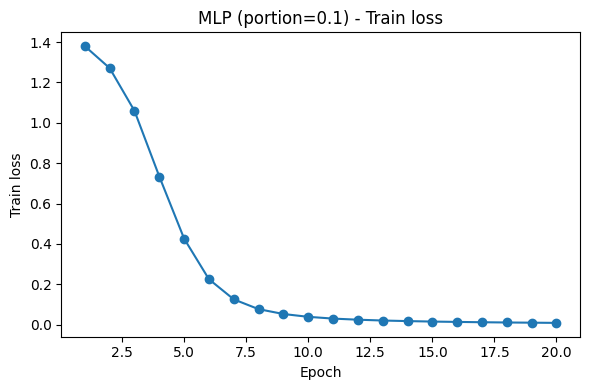

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_a, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'MLP (portion=0.1) - Train loss')
plt.tight_layout(); plt.show()


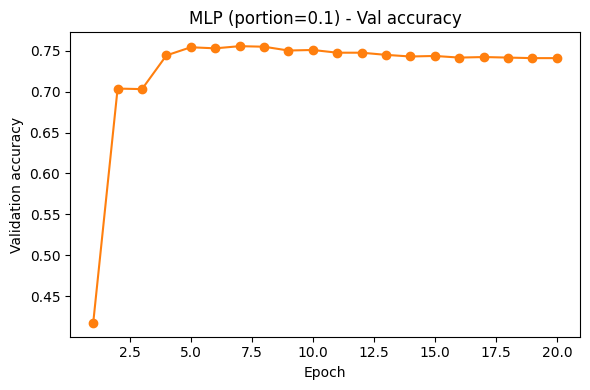

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_a, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'MLP (portion=0.1) - Val accuracy')
plt.tight_layout(); plt.show()


## (b) portion=0.2

In [7]:
# Data + TFIDF (portion=0.2)
portion = 0.2
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 451, test size: 1508


In [8]:
# Train MLP
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_b, val_accs_b = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.3495 | val acc 0.6180
Epoch 02 | train loss 1.0506 | val acc 0.7566
Epoch 03 | train loss 0.5594 | val acc 0.7938
Epoch 04 | train loss 0.2409 | val acc 0.7984
Epoch 05 | train loss 0.1164 | val acc 0.8037
Epoch 06 | train loss 0.0660 | val acc 0.8057
Epoch 07 | train loss 0.0434 | val acc 0.7997
Epoch 08 | train loss 0.0314 | val acc 0.7991
Epoch 09 | train loss 0.0243 | val acc 0.7931
Epoch 10 | train loss 0.0197 | val acc 0.7918
Epoch 11 | train loss 0.0167 | val acc 0.7924
Epoch 12 | train loss 0.0144 | val acc 0.7931
Epoch 13 | train loss 0.0128 | val acc 0.7918
Epoch 14 | train loss 0.0114 | val acc 0.7944
Epoch 15 | train loss 0.0104 | val acc 0.7938
Epoch 16 | train loss 0.0094 | val acc 0.7931
Epoch 17 | train loss 0.0086 | val acc 0.7931
Epoch 18 | train loss 0.0082 | val acc 0.7931
Epoch 19 | train loss 0.0078 | val acc 0.7924
Epoch 20 | train loss 0.0074 | val acc 0.7924


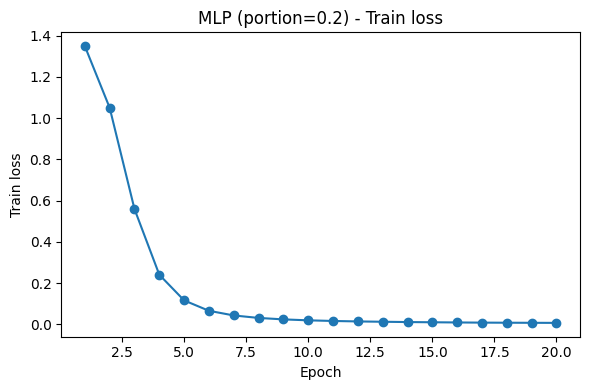

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_b, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'MLP (portion=0.2) - Train loss')
plt.tight_layout(); plt.show()


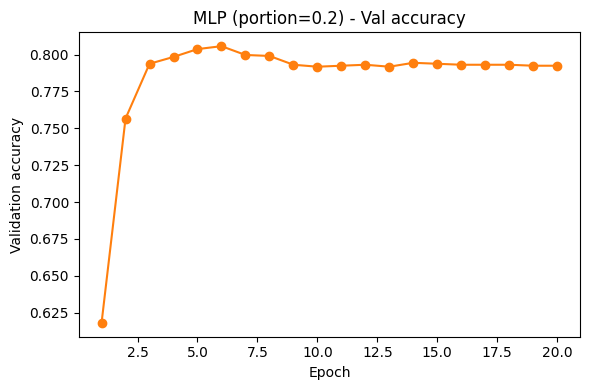

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_b, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'MLP (portion=0.2) - Val accuracy')
plt.tight_layout(); plt.show()


## (c) portion=0.5

In [11]:
# Data + TFIDF (portion=0.5)
portion = 0.5
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 1133, test size: 1508


In [12]:
# Train MLP
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_c, val_accs_c = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 1.1755 | val acc 0.8117
Epoch 02 | train loss 0.4364 | val acc 0.8382
Epoch 03 | train loss 0.1616 | val acc 0.8336
Epoch 04 | train loss 0.0774 | val acc 0.8329
Epoch 05 | train loss 0.0435 | val acc 0.8316
Epoch 06 | train loss 0.0292 | val acc 0.8249
Epoch 07 | train loss 0.0222 | val acc 0.8269
Epoch 08 | train loss 0.0183 | val acc 0.8263
Epoch 09 | train loss 0.0162 | val acc 0.8263
Epoch 10 | train loss 0.0144 | val acc 0.8249
Epoch 11 | train loss 0.0132 | val acc 0.8223
Epoch 12 | train loss 0.0128 | val acc 0.8236
Epoch 13 | train loss 0.0120 | val acc 0.8223
Epoch 14 | train loss 0.0118 | val acc 0.8223
Epoch 15 | train loss 0.0113 | val acc 0.8210
Epoch 16 | train loss 0.0114 | val acc 0.8229
Epoch 17 | train loss 0.0110 | val acc 0.8196
Epoch 18 | train loss 0.0112 | val acc 0.8223
Epoch 19 | train loss 0.0109 | val acc 0.8223
Epoch 20 | train loss 0.0107 | val acc 0.8176


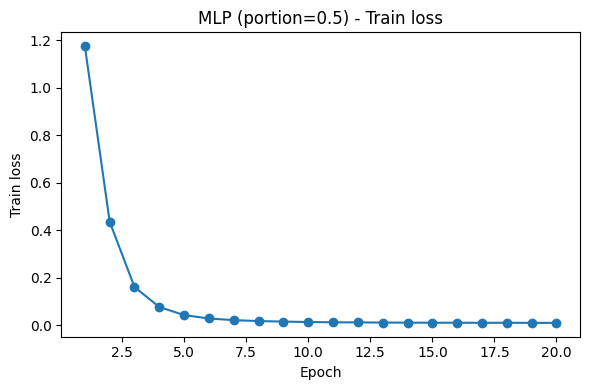

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_c, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'MLP (portion=0.5) - Train loss')
plt.tight_layout(); plt.show()


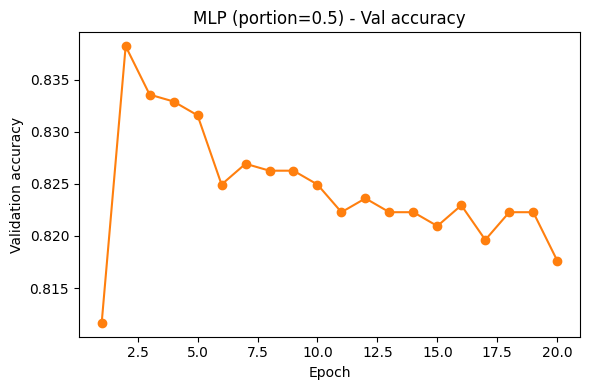

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_c, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'MLP (portion=0.5) - Val accuracy')
plt.tight_layout(); plt.show()


## (d) portion=1.0

In [15]:
# Data + TFIDF (portion=1.0)
portion = 1.0
x_train, y_train, x_test, y_test = get_data(categories=categories, portion=portion)

vectorizer = TfidfVectorizer(max_features=feature_dim)
X_train = vectorizer.fit_transform(x_train).toarray().astype(np.float32)
X_test  = vectorizer.transform(x_test).toarray().astype(np.float32)
y_train = np.array(y_train, dtype=np.int64)
y_test  = np.array(y_test,  dtype=np.int64)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test)),
                          batch_size=batch_size)

print(f'train size: {len(x_train)}, test size: {len(x_test)}')


train size: 2267, test size: 1508


In [16]:
# Train MLP
model = MLP(feature_dim, hidden_dim, num_labels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

train_losses_d, val_accs_d = train_and_eval(
    model, train_loader, test_loader, optimizer, criterion, epochs, device)


Epoch 01 | train loss 0.8680 | val acc 0.8501
Epoch 02 | train loss 0.2273 | val acc 0.8515
Epoch 03 | train loss 0.0968 | val acc 0.8475
Epoch 04 | train loss 0.0511 | val acc 0.8495
Epoch 05 | train loss 0.0326 | val acc 0.8462
Epoch 06 | train loss 0.0247 | val acc 0.8428
Epoch 07 | train loss 0.0205 | val acc 0.8428
Epoch 08 | train loss 0.0186 | val acc 0.8395
Epoch 09 | train loss 0.0173 | val acc 0.8362
Epoch 10 | train loss 0.0163 | val acc 0.8402
Epoch 11 | train loss 0.0159 | val acc 0.8355
Epoch 12 | train loss 0.0156 | val acc 0.8375
Epoch 13 | train loss 0.0160 | val acc 0.8382
Epoch 14 | train loss 0.0154 | val acc 0.8375
Epoch 15 | train loss 0.0154 | val acc 0.8375
Epoch 16 | train loss 0.0150 | val acc 0.8349
Epoch 17 | train loss 0.0153 | val acc 0.8375
Epoch 18 | train loss 0.0155 | val acc 0.8375
Epoch 19 | train loss 0.0149 | val acc 0.8336
Epoch 20 | train loss 0.0146 | val acc 0.8375


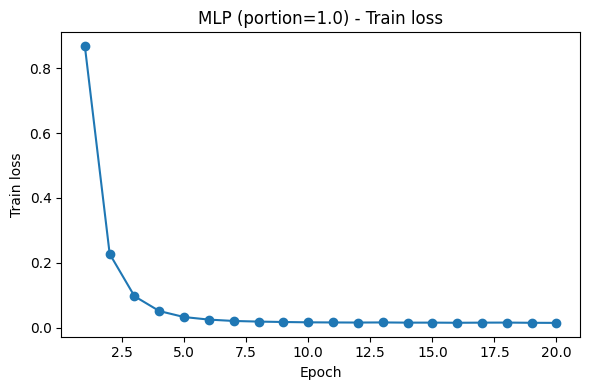

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), train_losses_d, marker='o')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train loss')
ax.set_title(f'MLP (portion=1.0) - Train loss')
plt.tight_layout(); plt.show()


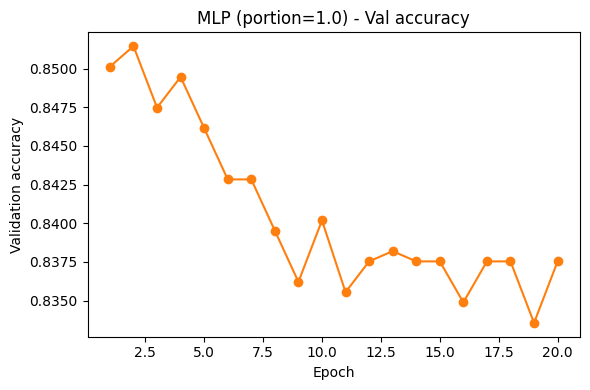

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, epochs + 1), val_accs_d, marker='o', color='tab:orange')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
ax.set_title(f'MLP (portion=1.0) - Val accuracy')
plt.tight_layout(); plt.show()
